In [7]:
%matplotlib inline

import sys
import yaml
import copy

import torch
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../../')
sys.path.append('../../../../')

%load_ext autoreload
%autoreload 2
    
from computer_vision.yolov11_pose.data.dataset import YOLODataset
from computer_vision.yolov11_pose.utils import DEFAULT_CFG_DICT
from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.misc import alpha_bending, instance2mask
from computer_vision.yolov11_pose.cfg import get_cfg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
from matplotlib import patches
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

In [9]:
args=parser.parse_args('--deterministic'.split())

task='segment'
if task=='pose':
    data_dirpath='D:/data/ultralytics/coco8-pose'
    data_config='../../coco8-pose.yaml'
elif task=='detect':
    data_dirpath='D:/data/ultralytics/coco/images/train2017'
    data_config='../../coco.yaml'
elif task=='segment':
    data_dirpath='D:/data/ultralytics/coco8-seg'
    data_config='../../coco8-seg.yaml'
    
dataset=YOLODataset(args=args, data=data_config, task=task, img_path=data_dirpath, imgsz=640, cache=False,augment=True, 
                    hyp=DEFAULT_CFG_DICT, prefix='',rect=False,batch_size=16,stride=32,pad=0.5, single_cls=False,classes=None,
                fraction=1.,channels=3)
for i in range(4): print(dataset.labels[i]['cls'].shape)

hyp=get_cfg()

In data.dataset.YOLODataset.get_labels cache_path D:\data\ultralytics\coco8-seg\labels\train.cache
Scanning D:\data\ultralytics\coco8-seg\labels\train.cache... 8 images, 0 backgrounds, 0 corrupts
(8, 1)
(2, 1)
(2, 1)
(1, 1)


In [10]:
from __future__ import annotations

import math
import random
from copy import deepcopy
from typing import Any

import cv2
import numpy as np
import torch
from PIL import Image
from torch.nn import functional as F

from computer_vision.yolov11_pose.data.augment import BaseMixTransform, Mosaic, LetterBox, RandomPerspective, CopyPaste, RandomFlip, RandomHSV
from computer_vision.yolov11_pose.utils.instance import Instances
from computer_vision.yolov11_pose.utils.metrics import bbox_ioa
from computer_vision.yolov11_pose.utils.viz import general_skeleton_overlay

In [11]:
indx=1
labels=dataset.get_image_and_label(indx) # main label
original_labels=copy.deepcopy(labels)

augmenter=RandomHSV(hgain=0.015, sgain=0.7, vgain=0.4)
final_labels=augmenter(labels)

0 --------------------------------------------------
img  (426, 640, 3) height 426, width 640
1 --------------------------------------------------
img  (426, 640, 3) height 426, width 640


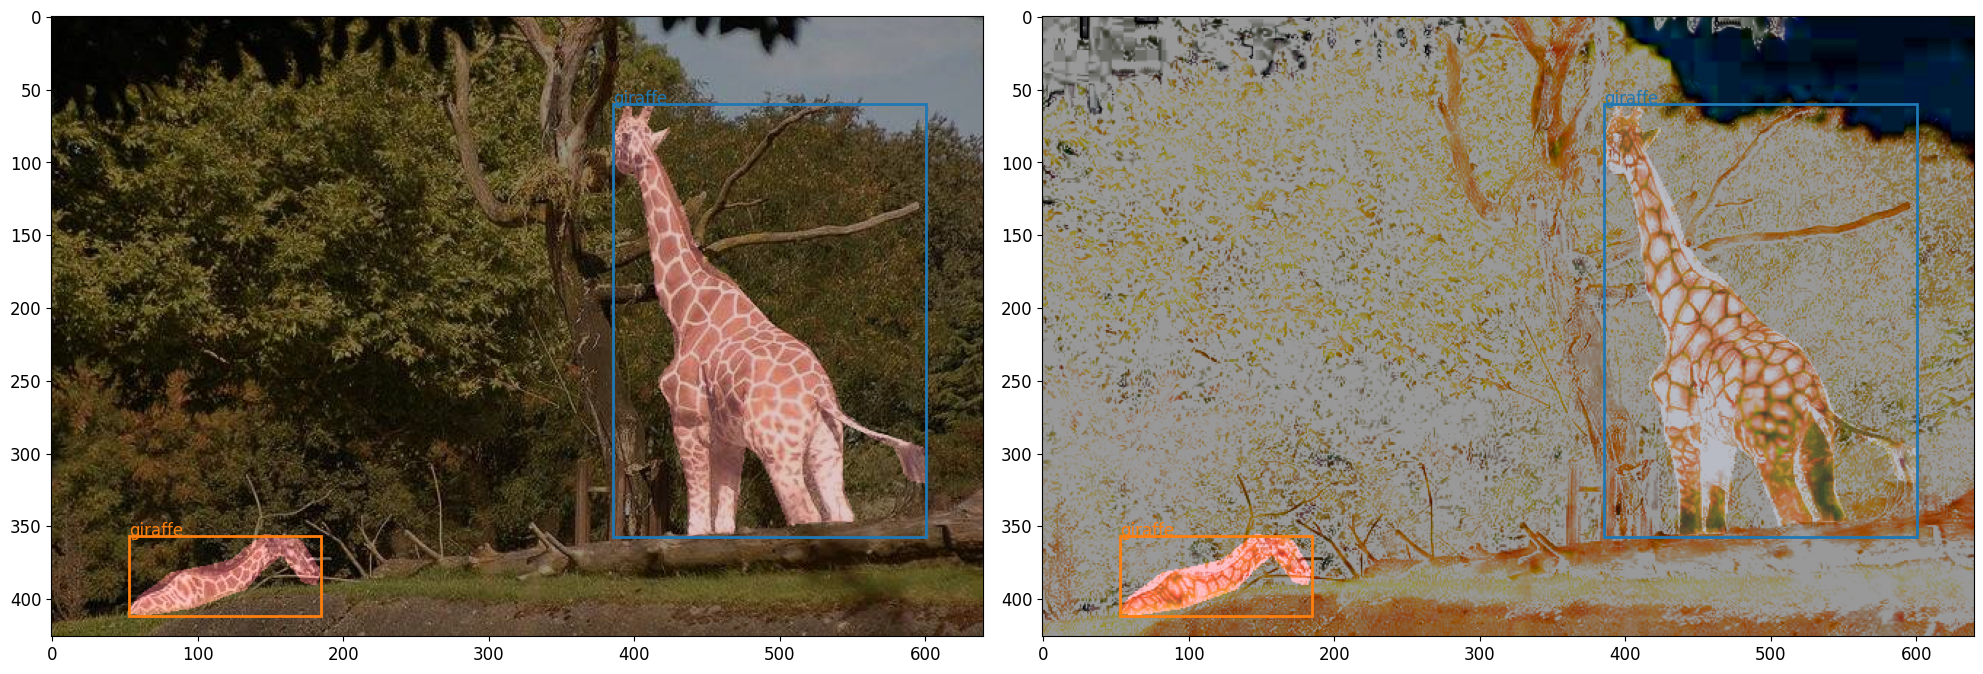

In [12]:
_, ax=plt.subplots(1,2,figsize=(20,8))
for i, labels in enumerate([original_labels, final_labels]):
    print(i,'-'*50)
    if labels is None: continue
    classes=[dataset.data['names'][int(c)] for c in labels['cls'].flatten()]
    img=labels['img']
    height, width=img.shape[:2]
    print('img ', img.shape, f'height {height}, width {width}')
    instances=copy.deepcopy(labels['instances'])
    if instances._bboxes.format=='xywh': instances.convert_bbox('xyxy')
    if instances.normalized: instances.denormalize(width, height)
    boxes=instances.bboxes
    if hasattr(labels['instances'], 'segments') and len(getattr(labels['instances'], 'segments')):
        mask=instance2mask(image=img, instance=labels['instances'])
        ax[i].imshow(alpha_bending(mask, img[...,::-1], 0.4))
    elif instances.keypoints is not None:
        img=general_skeleton_overlay(img_bgr=img, class_names=classes, bboxes=boxes, keypoints=instances.keypoints)
        ax[i].imshow(img[...,::-1])
    else: ax[i].imshow(img[...,::-1])
    if instances.keypoints is None:
        for j, (box,cls) in enumerate(zip(boxes, classes)):
            # Create a Rectangle patch
            rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
            # Add the patch to the Axes
            ax[i].add_patch(rect)
            ax[i].text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)
plt.tight_layout()